# Fleet Replacement - One-Shot Lookahead by Forecast Profile

This notebook mirrors the structure of the linopy usage demo, but:

1. Uses initial information-state values directly from the environment config
2. Builds a 10-vehicle deterministic initial fleet of DT vehicles with staggered ages
3. Runs the lookahead model exactly once for each forecast profile


In [1]:
from importlib import reload
from pathlib import Path

import pandas as pd

import plot_helpers
from fleet_replacement.config import load_env_config, load_lookahead_config
from fleet_replacement.policies.lookahead_model import (
    VehicleType,
    FleetReplacementData,
    ForecastParams,
    InfoState,
    InitialVehicle,
    ModelParams,
    best_immediate_actions,
    build_model,
    make_forecast,
    solve,
)

reload(plot_helpers)
from plot_helpers import plot_fleet_composition

## 1. Load base environment config

The environment config provides the initial market values and core model parameters.


In [2]:
repo_root = Path("..")
env_config_path = repo_root / "configs" / "env.yaml"

env_config = load_env_config(env_config_path)
env_config

EnvConfig(simulation_period=SimulationPeriodConfig(base_year=2026, final_year=2046), diesel_price=StochasticPriceConfig(initial_price=18.0, growth_rate=0.02, volatility=0.02), electricity_price=StochasticPriceConfig(initial_price=3.0, growth_rate=0.0, volatility=0.04), DT_price=DTPriceConfig(initial_price=1800000.0), BET_price=BETPriceConfig(initial_price=3200000.0, long_term_mean=1800000.0, mean_reversion_strength=0.2, purchase_price_volatility=100000.0), BET_productivity=BETProductivityConfig(start=0.7, max=0.95, k_min=0.15, k_max=0.6, t0_min=2030, t0_max=2042), operational=OperationalConfig(fuel_consumption_l_per_km=0.6, electricity_consumption_kwh_per_km=2.5, driver_salary_annual=800000.0, income_per_km=30.0, annual_mileage_km=130000.0), economic=EconomicConfig(interest_rate=0.041, loan_fraction=0.8, economic_lifetime=5, discount_factor=0.96), vehicle_management=VehicleManagementConfig(fleet_size=8, max_age=7, max_replacements=1), residual_value=ResidualValueConfig(initial_deprecia

## 2. Build initial information state from config

Uses base-year and initial prices/productivity exactly as configured.


In [3]:
info_state = InfoState(
    year=env_config.simulation_period.base_year,
    energy_price_diesel=env_config.diesel_price.initial_price,
    energy_price_electricity=env_config.electricity_price.initial_price,
    purchase_price_DT=env_config.DT_price.initial_price,
    purchase_price_BET=env_config.BET_price.initial_price,
    productivity_BET=env_config.BET_productivity.start,
)
info_state

InfoState(year=2026, energy_price_diesel=18.0, energy_price_electricity=3.0, purchase_price_DT=1800000.0, purchase_price_BET=3200000.0, productivity_BET=0.7)

## 3. Build deterministic 10-slot initial DT fleet

Mimics the environment's \_initial_fleet age pattern: age[i] = i % (max_age + 1).
All slots start as DT with DT initial purchase price.


In [4]:
fleet_size = env_config.vehicle_management.fleet_size
max_age = env_config.vehicle_management.max_age
dt_price0 = env_config.DT_price.initial_price

initial_fleet = [
    InitialVehicle(
        vehicle_type=VehicleType.DT,
        age=i % (max_age + 1),
        purchase_price=dt_price0,
    )
    for i in range(fleet_size)
]

for slot, v in enumerate(initial_fleet):
    print(
        f"slot {slot:>2}: {v.vehicle_type:>3}  age={v.age}  purchase_price={v.purchase_price:,.0f}"
    )

slot  0:  DT  age=0  purchase_price=1,800,000
slot  1:  DT  age=1  purchase_price=1,800,000
slot  2:  DT  age=2  purchase_price=1,800,000
slot  3:  DT  age=3  purchase_price=1,800,000
slot  4:  DT  age=4  purchase_price=1,800,000
slot  5:  DT  age=5  purchase_price=1,800,000
slot  6:  DT  age=6  purchase_price=1,800,000
slot  7:  DT  age=7  purchase_price=1,800,000


## 4. Define forecast profiles

Each profile file provides horizon and forecast rates for one one-shot model run.


In [5]:
profile_paths = {
    "baseline": repo_root / "configs" / "lookahead_baseline.yaml",
    "conservative": repo_root / "configs" / "lookahead_conservative.yaml",
    "optimistic": repo_root / "configs" / "lookahead_optimistic.yaml",
}
profile_paths

{'baseline': WindowsPath('../configs/lookahead_baseline.yaml'),
 'conservative': WindowsPath('../configs/lookahead_conservative.yaml'),
 'optimistic': WindowsPath('../configs/lookahead_optimistic.yaml')}

## 5. One-shot solve function

For each profile: build forecast, build model, solve once, extract first-period actions.


In [6]:
def run_one_profile(profile_name: str, profile_path: Path):
    lookahead_cfg = load_lookahead_config(profile_path)

    params = ModelParams.from_env_config(env_config, horizon=lookahead_cfg.horizon)

    data = FleetReplacementData(
        params=params,
        info_state=info_state,
        initial_fleet=initial_fleet,
    )

    rates = lookahead_cfg.forecast_rates
    fp = ForecastParams(
        diesel_price_growth=rates.diesel_price_growth,
        electricity_price_growth=rates.electricity_price_growth,
        purchase_price_growth_DT=rates.purchase_price_growth_DT,
        BET_price_gap_closure_rate=rates.BET_price_gap_closure_rate,
        BET_productivity_growth=rates.BET_productivity_growth,
    )

    forecast = make_forecast(
        info_state,
        horizon=params.horizon,
        BET_productivity_max=params.BET_productivity_max,
        forecast_params=fp,
    )

    model = build_model(data, forecast)

    # Prefer strict optimal solve; if the solver reports 'unknown' but yields
    # a usable solution in this session, keep it for plotting/comparison.
    status, condition = "ok", "optimal"
    try:
        model = solve(model)
    except RuntimeError:
        import warnings

        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", category=UserWarning, module="linopy")
            status, condition = model.solve(solver_name="highs", output_flag=False)
        if model.solution is None or "x" not in model.solution:
            raise

    decisions = best_immediate_actions(model, data)
    decision_labels = [str(d) for d in decisions]

    # Plot immediately after solve using the solved model (no re-solving).
    plot_fleet_composition(model, initial_fleet=initial_fleet)

    return {
        "profile": profile_name,
        "horizon": lookahead_cfg.horizon,
        "diesel_price_growth": rates.diesel_price_growth,
        "electricity_price_growth": rates.electricity_price_growth,
        "purchase_price_growth_DT": rates.purchase_price_growth_DT,
        "BET_price_gap_closure_rate": rates.BET_price_gap_closure_rate,
        "BET_productivity_growth": rates.BET_productivity_growth,
        "objective_value": float(model.objective.value),
        "status": status,
        "condition": condition,
        "n_replace_dt": sum(x == "Replace_DT" for x in decision_labels),
        "n_replace_bet": sum(x == "Replace_BET" for x in decision_labels),
        "n_keep": sum(x == "Keep" for x in decision_labels),
        "decisions": decision_labels,
        "model": model,
        "forecast": forecast,
        "params": params,
    }

## 6. Run once per profile

This executes exactly one model solve per profile file.


c:\git\KTH\fleet-replacement\.venv\Lib\site-packages\linopy\common.py:492: UserWarning: Coordinates across variables not equal. Perform outer join.
  warn(


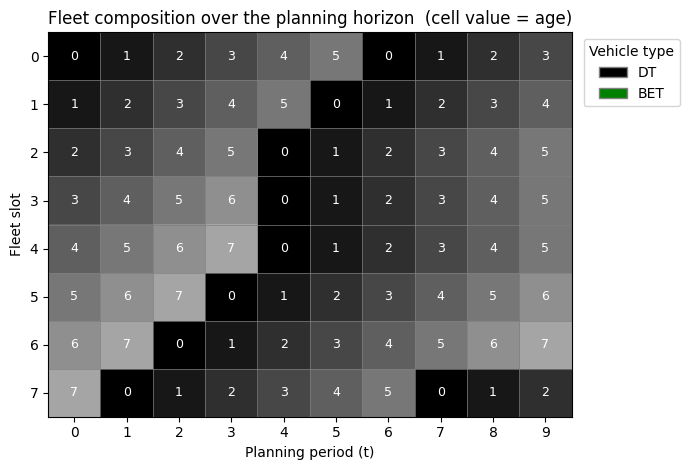

c:\git\KTH\fleet-replacement\.venv\Lib\site-packages\linopy\common.py:492: UserWarning: Coordinates across variables not equal. Perform outer join.
  warn(


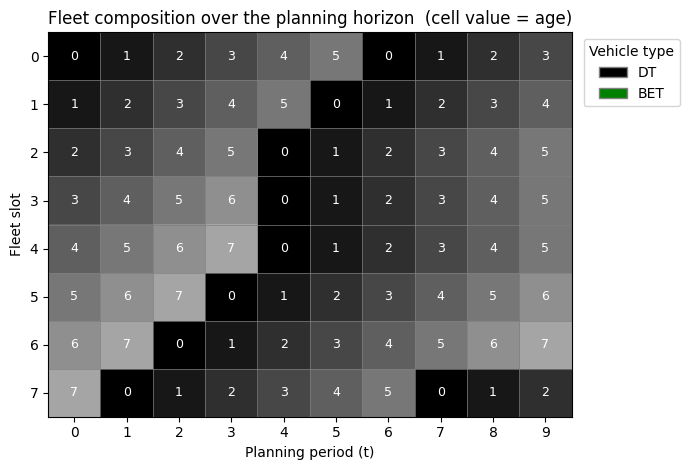

c:\git\KTH\fleet-replacement\.venv\Lib\site-packages\linopy\common.py:492: UserWarning: Coordinates across variables not equal. Perform outer join.
  warn(


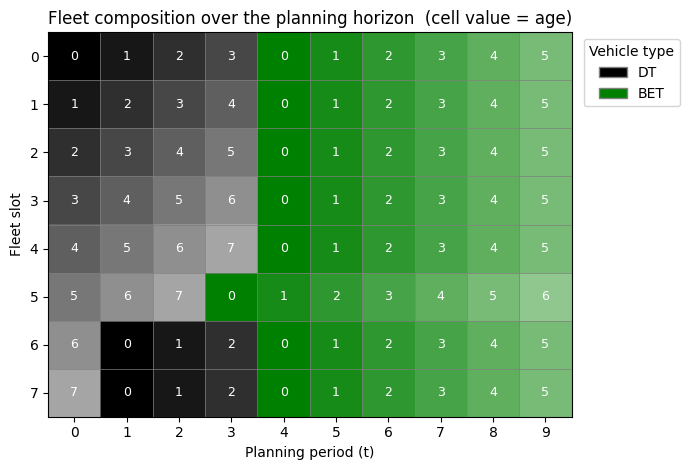

,profile,horizon,diesel_price_growth,electricity_price_growth,purchase_price_growth_DT,BET_price_gap_closure_rate,BET_productivity_growth,objective_value,status,condition,n_replace_dt,n_replace_bet,n_keep
0,baseline,10,0.00,0.0,0.0,0.00,0.00,1.588642e+08,ok,optimal,1,0,7
1,conservative,10,0.01,0.0,0.0,0.02,0.01,1.549451e+08,ok,optimal,1,0,7
2,optimistic,10,0.03,0.0,0.0,0.05,0.05,1.560464e+08,ok,optimal,2,0,6


In [7]:
results = []
for profile_name, profile_path in profile_paths.items():
    results.append(run_one_profile(profile_name, profile_path))

# Cache solved objects once; later plotting cells reuse this dict.
profile_artifacts = {
    row["profile"]: {
        "params": row["params"],
        "forecast": row["forecast"],
        "model": row["model"],
        "status": row["status"],
        "condition": row["condition"],
    }
    for row in results
}

summary_df = pd.DataFrame(
    [
        {
            k: v
            for k, v in row.items()
            if k not in {"decisions", "model", "forecast", "params"}
        }
        for row in results
    ]
)
summary_df

## 7. Slot-level first-period decisions by profile

Each row is one fleet slot and the corresponding t=0 action.


In [8]:
slot_rows = []
for row in results:
    for slot, decision in enumerate(row["decisions"]):
        slot_rows.append(
            {
                "profile": row["profile"],
                "slot": slot,
                "action_t0": decision,
            }
        )

actions_df = pd.DataFrame(slot_rows)
actions_df

,profile,slot,action_t0
0,baseline,0,Keep
1,baseline,1,Keep
2,baseline,2,Keep
3,baseline,3,Keep
4,baseline,4,Keep
5,baseline,5,Keep
6,baseline,6,Keep
7,baseline,7,Replace_DT
8,conservative,0,Keep
9,conservative,1,Keep


## 9. Combined forecast plot for all profiles

Uses the same 1x3 structure as the existing forecast helper, but overlays baseline, conservative, and optimistic in each panel.


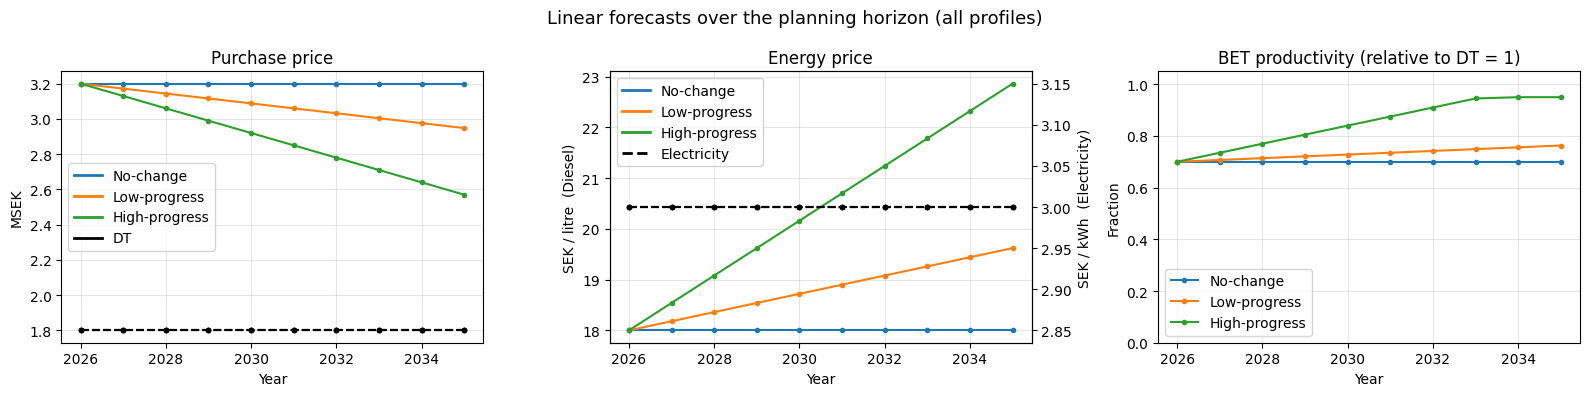

In [9]:
import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import numpy as np

profile_colors = {
    "baseline": "tab:blue",
    "conservative": "tab:orange",
    "optimistic": "tab:green",
}
profile_labels = {
    "baseline": "No-change",
    "conservative": "Low-progress",
    "optimistic": "High-progress",
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.patch.set_alpha(0)
for ax in axes:
    ax.set_facecolor("none")

# --- Panel 0: Purchase prices ---
ax0 = axes[0]
for profile_name, artifact in profile_artifacts.items():
    params = artifact["params"]
    forecast = artifact["forecast"]
    years = info_state.year + np.arange(params.horizon)
    c = profile_colors.get(profile_name, None)

    ax0.plot(
        years,
        forecast.purchase_price_DT / 1e6,
        color="black",
        linestyle="--",
        marker="o",
        markersize=3,
        label=f"{profile_labels.get(profile_name, profile_name)} DT",
    )
    ax0.plot(
        years,
        forecast.purchase_price_BET / 1e6,
        color=c,
        linestyle="-",
        marker="o",
        markersize=3,
        label=f"{profile_labels.get(profile_name, profile_name)} BET",
    )
ax0.set_title("Purchase price")
ax0.set_ylabel("MSEK")
ax0.set_xlabel("Year")
ax0.grid(True, alpha=0.3)

profile_handles = [
    mlines.Line2D(
        [],
        [],
        color=profile_colors[p],
        linewidth=2,
        label=profile_labels.get(p, p),
    )
    for p in profile_artifacts.keys()
]
series_handles_0 = [
    mlines.Line2D([], [], color="black", linestyle="-", linewidth=2, label="DT"),
    # mlines.Line2D([], [], color="black", linestyle="--", linewidth=2, label="BET"),
]
ax0.legend(handles=profile_handles + series_handles_0, loc="best")

# --- Panel 1: Energy prices (dual y-axis) ---
ax_d = axes[1]
ax_e = ax_d.twinx()
ax_e.set_facecolor("none")
for profile_name, artifact in profile_artifacts.items():
    params = artifact["params"]
    forecast = artifact["forecast"]
    years = info_state.year + np.arange(params.horizon)
    c = profile_colors.get(profile_name, None)

    ax_d.plot(
        years,
        forecast.energy_price_diesel,
        color=c,
        linestyle="-",
        marker="o",
        markersize=3,
    )
    ax_e.plot(
        years,
        forecast.energy_price_electricity,
        color="black",
        linestyle="--",
        marker="o",
        markersize=3,
    )

ax_d.set_title("Energy price")
ax_d.set_xlabel("Year")
ax_d.set_ylabel("SEK / litre  (Diesel)", color="black")
ax_e.set_ylabel("SEK / kWh  (Electricity)", color="black")
ax_d.grid(True, alpha=0.3)

series_handles_1 = [
    # mlines.Line2D([], [], color="black", linestyle="-", linewidth=2, label="Diesel"),
    mlines.Line2D(
        [], [], color="black", linestyle="--", linewidth=2, label="Electricity"
    ),
]
ax_d.legend(handles=profile_handles + series_handles_1, loc="best")

# --- Panel 2: BET productivity ---
ax2 = axes[2]
for profile_name, artifact in profile_artifacts.items():
    params = artifact["params"]
    forecast = artifact["forecast"]
    years = info_state.year + np.arange(params.horizon)
    c = profile_colors.get(profile_name, None)

    ax2.plot(
        years,
        forecast.productivity_BET,
        color=c,
        linestyle="-",
        marker="o",
        markersize=3,
        label=profile_labels.get(profile_name, profile_name),
    )
ax2.set_title("BET productivity (relative to DT = 1)")
ax2.set_ylabel("Fraction")
ax2.set_xlabel("Year")
ax2.set_ylim(0, 1.05)
ax2.grid(True, alpha=0.3)
ax2.legend(loc="best")

fig.suptitle("Linear forecasts over the planning horizon (all profiles)", fontsize=13)
plt.tight_layout()
plt.show()